<a href="https://colab.research.google.com/github/Jum-eng/Pencil-Sketch-Conversion/blob/main/Pencil_Sketch_Conversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install opencv-python-headless pillow -q


STEP 1: Click 'Choose Files' below to upload your image



Saving jA.jpg to jA (2).jpg

Uploaded: jA (2).jpg

STEP 2: Here is your original image and pencil sketch



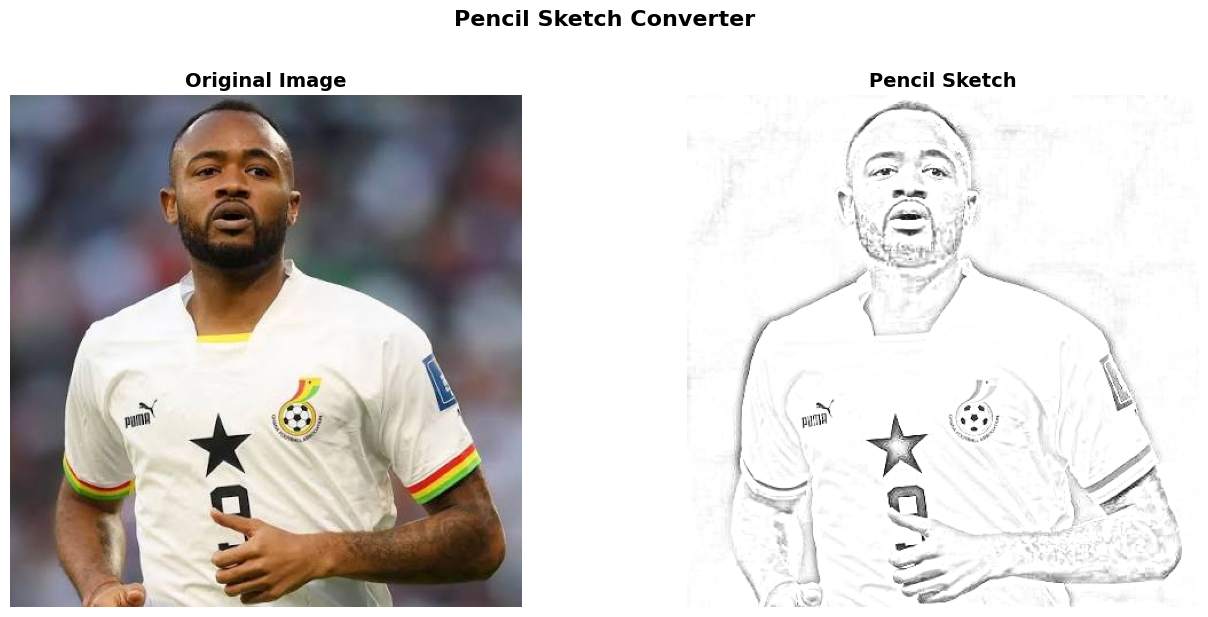


STEP 3: Downloading your sketch now...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

sketch_output.png downloaded to computer!


In [16]:
import cv2
import numpy as np
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt
import io

images = {"original": None, "sketch": None}

def convert_to_sketch(img):
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    inverted_img = cv2.bitwise_not(gray_img)
    blurred_img = cv2.GaussianBlur(inverted_img, (21, 21), sigmaX=0, sigmaY=0)
    inverted_blur_img = cv2.bitwise_not(blurred_img)
    sketch_img = cv2.divide(gray_img, inverted_blur_img, scale=256.0)
    return sketch_img

# Image Upload your
print("\nSTEP 1: Click 'Choose Files' below to upload your image\n")

uploaded = files.upload()

if not uploaded:
    print("No file uploaded. Re-run the cell and choose a file.")
else:
    filename = list(uploaded.keys())[0]
    print(f"\nUploaded: {filename}")

    # Read image
    np_arr = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

    # Store original
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images["original"] = Image.fromarray(img_rgb)

    # Convert to sketch
    sketch_img = convert_to_sketch(img)
    images["sketch"] = Image.fromarray(sketch_img)

    # Display original + sketch side by side
    print("\nSTEP 2: Here is your original image and pencil sketch\n")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image", fontsize=14, fontweight='bold')
    axes[0].axis("off")

    axes[1].imshow(sketch_img, cmap="gray")
    axes[1].set_title("Pencil Sketch", fontsize=14, fontweight='bold')
    axes[1].axis("off")

    plt.suptitle("Pencil Sketch Converter", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # STEP 3: Download the sketch
    print("\nSTEP 3: Downloading your sketch now...\n")
    buf = io.BytesIO()
    images["sketch"].save(buf, format="PNG")
    buf.seek(0)
    with open("sketch_output.png", "wb") as f:
        f.write(buf.read())
    files.download("sketch_output.png")
    print("sketch_output.png downloaded to computer!")